## SVM Kernels and Decision Boundaries:

Follow-up to `svm_implementation.ipynb`. Here we use the 2D `make_moons` dataset (rather than the breast cancer data) so kernel decision boundaries can actually be visualized, then tune an RBF SVM with `GridSearchCV`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from mlxtend.plotting import plot_decision_regions

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

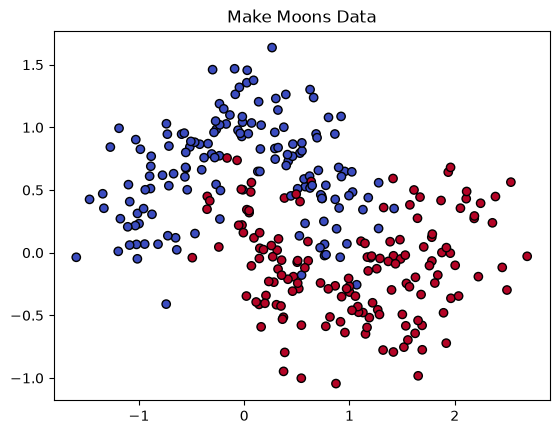

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.title("Make Moons Data")
plt.show()

### 1. Decision boundaries by kernel:

`plot_decision_regions` from `mlxtend` needs integer class labels and a fitted classifier; it re-derives the grid from the data passed in, so we pass the scaled training data here.

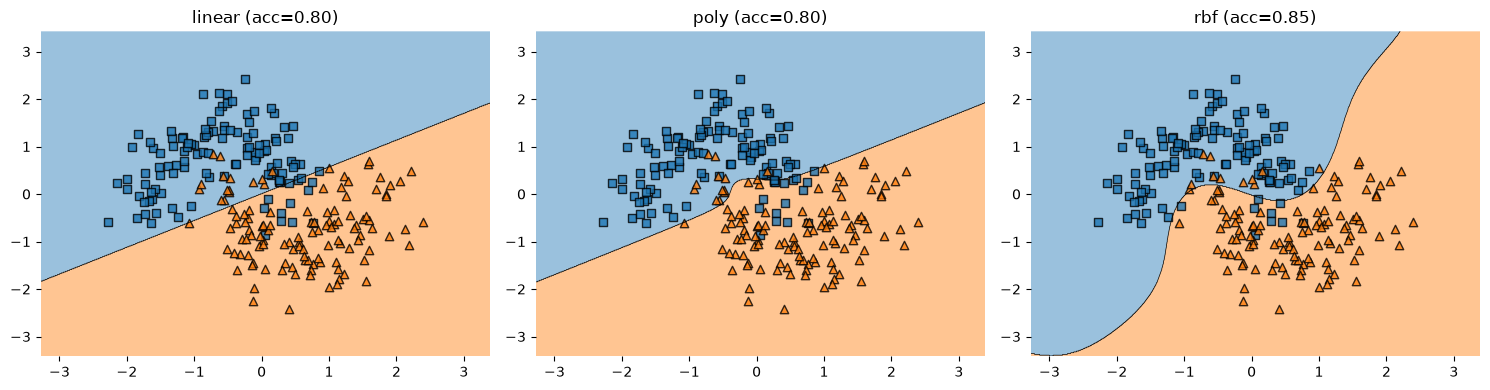

In [6]:
kernels = ["linear", "poly", "rbf"]

fig, axes = plt.subplots(1, len(kernels), figsize=(15, 4))
for ax, kernel in zip(axes, kernels):
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    plot_decision_regions(X_train_s, y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train, clf=model, ax=ax, legend=0)
    ax.set_title(f"{kernel} (acc={acc:.2f})")
    
plt.tight_layout()
plt.show()

The linear kernel can only draw a straight line, so it struggles with the interleaving moons. `poly` and `rbf` can curve around the classes and fit the data much better.

### 2. Tuning the RBF kernel with GridSearchCV:

In [7]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.01, 0.1, 1, 10],
}

grid = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

Best params: {'C': 10, 'gamma': 10}
Best CV accuracy: 0.9292


In [8]:
best_model = grid.best_estimator_
test_acc = accuracy_score(y_test, best_model.predict(X_test_s))
print("Test accuracy with best params:", round(test_acc, 4))
print(classification_report(y_test, best_model.predict(X_test_s)))

Test accuracy with best params: 0.8667
              precision    recall  f1-score   support

           0       0.96      0.77      0.85        30
           1       0.81      0.97      0.88        30

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60



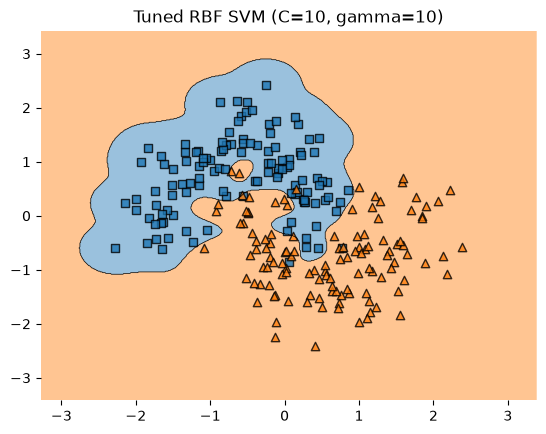

In [9]:
plot_decision_regions(X_train_s, y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train, clf=best_model, legend=0)
plt.title(f"Tuned RBF SVM (C={grid.best_params_['C']}, gamma={grid.best_params_['gamma']})")
plt.show()

**Takeaways**:

- On non-linearly-separable data like `make_moons`, kernel choice matters a lot more than it did on the (nearly linear) breast cancer data.
- `GridSearchCV` with 5-fold CV picks `C`/`gamma` by cross-validated accuracy rather than a single train/test split, which is more reliable than the one-parameter-at-a-time sweep.